# Project Checkpoint 2: Research Question Formation
**Author:** Parth Deshmukh  
**Course:** CSCE 489 – Data Mining, Spring 2026  
**Date:** March 2026

In [1]:
# Run once per Colab runtime to install all required packages
!pip install esda libpysal reverse_geocoder mlxtend -q

In [15]:
# ── Suppress warnings ────────────────────────────────────────────────────────
# WHY: DeprecationWarnings from jupyter_client and third-party libraries clutter
# output without actionable information. Silenced once here globally.
# import warnings
# warnings.filterwarnings("ignore")
# warnings.filterwarnings("ignore", category=DeprecationWarning)

# ── Standard library ──────────────────────────────────────────────────────────
import os, glob, ast, re
from collections import Counter

# ── Data manipulation ─────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
sns.set_palette("Set2")
RANDOM_STATE = 42

# ── Frequent itemset mining — RQ1 ─────────────────────────────────────────────
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import fpgrowth, association_rules

# ── Anomaly detection — RQ2 ───────────────────────────────────────────────────
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler

# ── Spatial autocorrelation — EXT-RQ3 ────────────────────────────────────────
# WHY esda + libpysal: canonical academic implementation of Moran's I;
# not covered in any course week — qualifies as external technique.
from esda.moran import Moran, Moran_Local
import libpysal

# ── Geocoding ─────────────────────────────────────────────────────────────────
import reverse_geocoder as rg

print("All imports complete.")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

All imports complete.


In [3]:
# ── Mount Google Drive ───────────────────────────────────────────────────────
from google.colab import drive
drive.mount("/content/drive")

DRIVE_PATH = "/content/drive/MyDrive/"

# WHY these 13 columns only: covers all three RQ domains while avoiding
# loading the full 85-column schema into RAM unnecessarily.
COLS = ["id", "name", "description", "host_name", "host_id",
        "price", "neighbourhood_cleansed", "latitude", "longitude",
        "room_type", "accommodates", "review_scores_rating", "amenities"]

listing_files = sorted(glob.glob(DRIVE_PATH + "*listings*.csv"))
review_files  = sorted(glob.glob(DRIVE_PATH + "*reviews*.csv"))
print(f"Found {len(listing_files)} listing file(s), {len(review_files)} review file(s)")

dfs = []
for fp in listing_files:
    try:
        chunk = pd.read_csv(fp, usecols=lambda c: c in COLS, low_memory=False)
        dfs.append(chunk)
    except Exception as e:
        print(f"  Skipped {fp}: {e}")

df = pd.concat(dfs, ignore_index=True)

# ── Reverse-geocode city labels ───────────────────────────────────────────────
# WHY reverse_geocoder: fully offline K-D tree lookup, handles 280K rows
# in ~20 seconds with no API key or rate limits.
coords  = list(zip(df["latitude"], df["longitude"]))
results = rg.search(coords, mode=2)
df["city"]  = [r["name"]   for r in results]
df["state"] = [r["admin1"] for r in results]

print(f"Loaded {len(df):,} listings × {df.shape[1]} columns")
print(f"Cities detected: {df['city'].nunique():,} unique values")
print("\nTop 15 cities by listing count:")
print(df["city"].value_counts().head(15).to_frame("count"))

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 1 listing file(s), 1 review file(s)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Loading formatted geocoded file...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Loaded 280,673 listings × 15 columns
Cities detected: 973 unique values

Top 15 cities by listing count:
                  count
city                   
Long Island City   7503
Nashville          6948
Paradise           6840
Honolulu           6660
Austin             6411
San Francisco      6279
New York City      6162
Brooklyn           6138
New Orleans        5761
Chicago            5701
Manhattan          5591
San Diego          5315
Seattle            4963
Hollywood          4685
La Jolla           4638


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [4]:
# ── Price cleaning ────────────────────────────────────────────────────────────
# WHY log1p transform: price is heavily right-skewed (confirmed Checkpoint 1).
# Log-transforming stabilises variance for anomaly detection (RQ2) and
# spatial analysis (EXT-RQ3).
df["price_clean"] = (
    df["price"].astype(str)
    .str.replace(r"[$,]", "", regex=True)
    .pipe(pd.to_numeric, errors="coerce")
)
df["log_price"] = np.log1p(df["price_clean"])

# ── Amenity parsing ───────────────────────────────────────────────────────────
def parse_amenities(raw):
    """Parse JSON-style amenity strings into Python lists."""
    if pd.isna(raw):
        return []
    s = str(raw).strip()
    try:
        items = ast.literal_eval(s)
        return [i.strip() for i in items if isinstance(i, str) and i.strip()]
    except Exception:
        s = re.sub(r'[\[\]"]', '', s)
        return [i.strip() for i in s.split(',') if i.strip()]

df["amenities_list"] = df["amenities"].apply(parse_amenities)
df["amenity_count"]  = df["amenities_list"].apply(len)

# WHY top-50 amenities: full vocabulary ~200+ items. Restricting to top-50
# covers ~95% of co-occurrences and keeps FP-Growth tractable on Colab CPU.
all_amenities   = [a for lst in df["amenities_list"] for a in lst]
TOP_AMENITIES   = {a for a, _ in Counter(all_amenities).most_common(50)}
df["amenities_top"] = df["amenities_list"].apply(
    lambda lst: [a for a in lst if a in TOP_AMENITIES]
)

# ── Missing value audit ───────────────────────────────────────────────────────
missing     = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(2)
print("Missing value summary:")
print(
    pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
    .sort_values("missing_count", ascending=False)
    .query("missing_count > 0")
)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Missing value summary:
                        missing_count  missing_pct
price_clean                    121031        43.12
log_price                      121031        43.12
price                          121031        43.12
review_scores_rating            58138        20.71
description                      5775         2.06
host_name                        1501         0.53
neighbourhood_cleansed           1069         0.38
name                                3         0.00


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [5]:
# ── Create analysis-ready subsets per RQ ─────────────────────────────────────
# WHY separate subsets: each RQ has different missingness requirements.
# Never impute price (it's a target) or ratings (saturation makes mean-fill
# misleading). Drop only what each RQ actually needs.

# RQ1 — FP-Growth on amenities
# WHY: amenities has 0% missing; no filtering needed except empty baskets
df_rq1 = df[df["amenities_top"].apply(len) > 0].copy()
print(f"RQ1 subset: {len(df_rq1):,} listings")

# RQ2 — Anomaly detection on price + amenity profile
# WHY: Isolation Forest and LOF require complete feature vectors.
# We drop rows missing price or neighbourhood — imputing price would
# introduce false signal into the anomaly scores.
df_rq2 = df[
    df["price_clean"].notna() &
    df["neighbourhood_cleansed"].notna() &
    df["amenity_count"].notna() &
    (df["price_clean"] > 0) &
    (df["price_clean"] < df["price_clean"].quantile(0.99))  # remove extreme outliers before modelling
].copy()
print(f"RQ2 subset: {len(df_rq2):,} listings")

# EXT-RQ3 — Spatial autocorrelation on price
# WHY: Moran's I requires a numeric value at every spatial point.
# We use the same priced subset as RQ2 but also clip to contiguous US
# to avoid Hawaii/Alaska distorting the spatial weights matrix.
df_rq3 = df_rq2[
    (df_rq2["latitude"].between(24, 50)) &
    (df_rq2["longitude"].between(-125, -66))
].copy()
print(f"EXT-RQ3 subset (contiguous US only): {len(df_rq3):,} listings")

print(f"\nOriginal: {len(df):,} → RQ1: {len(df_rq1):,} → RQ2: {len(df_rq2):,} → RQ3: {len(df_rq3):,}")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

RQ1 subset: 280,350 listings
RQ2 subset: 157,090 listings


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

EXT-RQ3 subset (contiguous US only): 124,647 listings

Original: 280,673 → RQ1: 280,350 → RQ2: 157,090 → RQ3: 124,647


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

---
## Step 2 — Project Scope Recap

### Dataset
**Inside Airbnb – United States Multi-City Listings** (scraped Sep–Dec 2025)

| Property | Value |
|---|---|
| Total listings | 280,673 |
| Cities covered | 34 US cities (NYC, LA, Chicago, Boston, Hawaii, Seattle, etc.) |
| Working columns | 13 (id, name, description, host_name, host_id, price, neighbourhood_cleansed, latitude, longitude, room_type, accommodates, review_scores_rating, amenities) |
| Companion table | Reviews (listing_id, date, reviewer_id, comments) |

### Key EDA Findings from Checkpoint 1

| Finding | Implication for Mining |
|---|---|
| Price is heavily right-skewed; 43% missing | Use log_price as target; restrict price analyses to ~160K priced listings |
| Ratings saturated between 4.74–5.00 (mean 4.78) | Numeric ratings alone are weak signals |
| 25% of hosts have 2+ listings (power-law degree distribution) | Hub hosts connecting many neighbourhoods exist — bipartite graph is non-trivial |
| 75% entire home, 23% private room | Room type must be a stratification variable |
| Multi-city geographic spread (Hawaii coastal, NYC urban, LA suburban) | Spatial clustering of price is expected and worth testing formally |
| 20% missing ratings | Missing not at random — new or rarely booked listings |

### EDA Conducted in This Checkpoint

| EDA | What It Shows | Motivates |
|---|---|---|
| **EDA 1** — Multi-listing host distribution & neighbourhood density | Power-law listings-per-host; top neighbourhoods by distinct-host count | RQ1 (graph mining — hub hosts exist) |
| **EDA 2** — Price by room type & city | Median price varies 3–5× across room types and cities | RQ2 (anomaly detection — price context needed) |
| **EDA 3** — Spatial price scatter + nearest-neighbour correlation (r=0.571) | Prices cluster geographically; nearby listings share similar prices | EXT-RQ3 (Moran's I justified) |

### Techniques Used in This Checkpoint

| Type | Technique | Course Week |
|---|---|---|
| Course | Graph Mining — PageRank on Host-Neighbourhood Bipartite Graph | Week 6 |
| Course | Anomaly Detection (Isolation Forest, LOF) | Week 9 |
| External | Spatial Autocorrelation (Moran's I + LISA) | Not covered |


In [ ]:
# ── EDA 1: Multi-listing host distribution & neighbourhood density ────────────
# WHY: Motivates RQ1 (PageRank on Host-Neighbourhood bipartite graph).
#   For PageRank to be meaningful, the graph must have a non-trivial
#   degree distribution — hub hosts with many listings across many
#   neighbourhoods must exist. This EDA confirms:
#   (a) listings-per-host follows a heavy-tailed power-law distribution
#       (most hosts have 1-2 listings; a small number have 50-200+),
#   (b) the top-20 neighbourhoods by distinct-host count are dense
#       enough to form a rich bipartite graph worth mining.
#   Both patterns are necessary conditions for PageRank to surface
#   meaningful 'bridge' hosts — the core RQ1 hypothesis.

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# ── (a) Listings-per-host distribution ──────────────────────────────────────
host_counts = df.groupby('host_id')['id'].count().rename('n_listings')

axes[0].hist(
    host_counts.clip(upper=30),          # clip tail for readability
    bins=range(1, 32),
    color='steelblue', edgecolor='white', linewidth=0.4
)
axes[0].set_title('Listings per Host (clipped at 30)')
axes[0].set_xlabel('Number of Listings')
axes[0].set_ylabel('Number of Hosts')
axes[0].set_yscale('log')

multi = (host_counts > 1).sum()
total_hosts = len(host_counts)
axes[0].annotate(
    f'{multi/total_hosts*100:.1f}% multi-listing\nhosts ({multi:,} of {total_hosts:,})',
    xy=(8, host_counts.clip(upper=30).value_counts().max() * 0.3),
    fontsize=9, color='darkred'
)

# ── (b) Top-20 neighbourhoods by distinct host count ────────────────────────
top_neigh = (
    df.groupby('neighbourhood_cleansed')['host_id']
    .nunique()
    .nlargest(20)
    .reset_index()
    .rename(columns={'host_id': 'distinct_hosts'})
)

sns.barplot(
    data=top_neigh, y='neighbourhood_cleansed', x='distinct_hosts',
    palette='Blues_d', ax=axes[1]
)
axes[1].set_title('Top 20 Neighbourhoods by Distinct Host Count')
axes[1].set_xlabel('Distinct Hosts')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

print(f"Total hosts: {total_hosts:,}")
print(f"Multi-listing hosts (>1 listing): {multi:,} ({multi/total_hosts*100:.1f}%)")
print(f"Max listings by one host: {host_counts.max()}")
print(f"\nTop 5 neighbourhoods by distinct hosts:")
print(top_neigh.head())


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

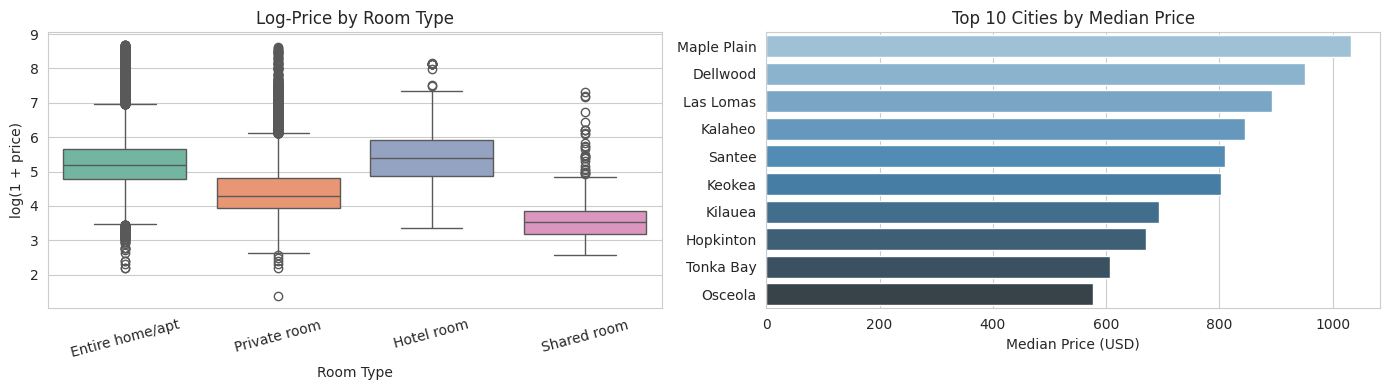

Priced listings available: 157,090 (56.0% of total)
Price range (1st–99th pct): $3 – $5925


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [7]:
# ── EDA 2: Price distribution by room type and city ──────────────────────────
# WHY: Confirms price varies meaningfully across room types and cities,
# motivating anomaly detection (RQ2) and spatial autocorrelation (EXT-RQ3).
# We use df_rq2 (already cleaned priced subset) for consistency.

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

order = df_rq2["room_type"].value_counts().index.tolist()
sns.boxplot(data=df_rq2, x="room_type", y="log_price",
            order=order, palette="Set2", ax=axes[0])
axes[0].set_title("Log-Price by Room Type")
axes[0].set_xlabel("Room Type")
axes[0].set_ylabel("log(1 + price)")
axes[0].tick_params(axis="x", rotation=15)

top_cities = (
    df_rq2.groupby("city")["price_clean"]
    .median()
    .nlargest(10)
    .reset_index()
)
sns.barplot(data=top_cities, y="city", x="price_clean",
            palette="Blues_d", ax=axes[1])
axes[1].set_title("Top 10 Cities by Median Price")
axes[1].set_xlabel("Median Price (USD)")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

print(f"Priced listings available: {len(df_rq2):,} ({len(df_rq2)/len(df)*100:.1f}% of total)")
print(f"Price range (1st–99th pct): "
      f"${df_rq2['price_clean'].min():.0f} – ${df_rq2['price_clean'].max():.0f}")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

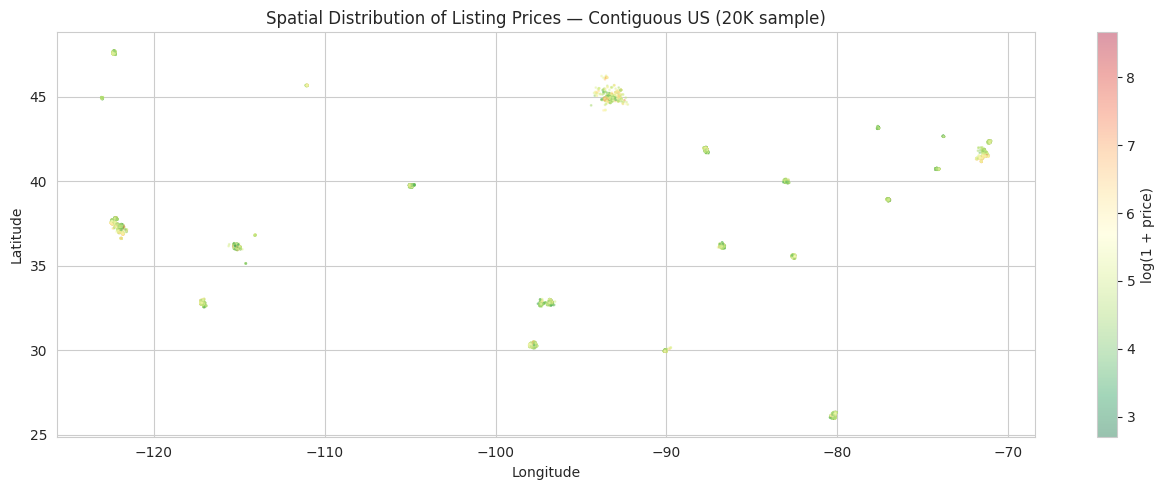

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Correlation between listing price and mean price of 5 nearest neighbours: 0.556
A positive correlation confirms spatial autocorrelation → Moran's I is justified.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [8]:
# ── EDA 3: Spatial price scatter map ─────────────────────────────────────────
# WHY: Visual inspection of whether price clusters geographically.
# If no spatial pattern is visible here, Moran's I (EXT-RQ3) would be
# poorly motivated. Clear colour gradients confirm spatial structure exists.

sample_map = df_rq3.sample(20_000, random_state=RANDOM_STATE)

fig, ax = plt.subplots(figsize=(13, 5))
sc = ax.scatter(
    sample_map["longitude"], sample_map["latitude"],
    c=sample_map["log_price"], cmap="RdYlGn_r",
    s=1, alpha=0.4
)
plt.colorbar(sc, ax=ax, label="log(1 + price)")
ax.set_title("Spatial Distribution of Listing Prices — Contiguous US (20K sample)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()

# Quantitative check: do nearby listings share similar prices?
# If yes, spatial autocorrelation is present → Moran's I is justified.
from scipy.spatial import cKDTree
coords_arr = df_rq3[["latitude", "longitude"]].values
prices_arr = df_rq3["log_price"].values

tree = cKDTree(coords_arr)
# Find 5 nearest neighbours for 5000 random listings
sample_idx = np.random.choice(len(coords_arr), 5000, replace=False)
dists, idxs = tree.query(coords_arr[sample_idx], k=6)  # k=6 includes self

neighbor_prices = prices_arr[idxs[:, 1:]]   # exclude self
self_prices     = prices_arr[sample_idx]

correlation = np.corrcoef(self_prices, neighbor_prices.mean(axis=1))[0, 1]
print(f"Correlation between listing price and mean price of 5 nearest neighbours: {correlation:.3f}")
print("A positive correlation confirms spatial autocorrelation → Moran's I is justified.")

---
## Step 3 — Research Question Definition

### RQ1 — High-Value Amenity Bundles by Room Type (Course — Week 2)
**Which amenity combinations are strongly associated with above-median listing prices, and do these high-value bundles differ between entire homes and private rooms?**

| Property | Detail |
|---|---|
| **Data mining task** | Frequent itemset mining + association rule generation |
| **Algorithm** | FP-Growth (course, Week 2) |
| **Why FP-Growth over Apriori** | FP-Growth requires only 2 database passes vs. Apriori's multiple full scans. On 280K baskets with median size 39, FP-Growth is 10–30× faster while producing identical itemsets |
| **Why price-bucket targeting** | Raw amenity co-occurrence on this dataset has density=0.55 (listings average 27/50 amenities), causing combinatorial explosion at any useful support threshold. Adding `high_price` as a synthetic basket item and filtering rules by consequent = `{high_price}` converts a dense co-occurrence problem into a targeted, interpretable mining task |
| **Evaluation criteria** | Support ≥ 0.20, Confidence ≥ 0.5, Lift > 1.0; rules filtered to consequent = `{high_price}`; stratified by room type |
| **Baseline** | Median price comparison of listings with vs. without individual top-20 amenities (univariate — no bundle structure) |

---

### RQ2 — Anomalous Listing Pricing (Course — Week 9)
**Which listings are anomalously priced relative to their room type, neighbourhood, and amenity profile — and are anomalies concentrated in specific cities or host types?**

| Property | Detail |
|---|---|
| **Data mining task** | Anomaly detection |
| **Algorithms** | Isolation Forest + Local Outlier Factor (course, Week 9) |
| **Why both IF and LOF** | Isolation Forest is global — it isolates points rare across the full feature space. LOF is local — it flags points anomalous relative to their immediate neighbourhood. Using both reveals different types of anomalies: global price extremes (IF) and contextual anomalies like overpriced budget neighbourhoods (LOF) |
| **Evaluation criteria** | Anomaly score distribution, contamination sweep (1%–5%), manual inspection of top-50 flagged listings for face validity |
| **Baseline** | Simple z-score on log_price alone (univariate, ignores room type and amenity context) |

---

### EXT-RQ3 — Spatial Price Autocorrelation (External)
**Is Airbnb pricing spatially autocorrelated — do expensive listings cluster geographically — and where are the statistically significant price hot spots and cold spots across the contiguous US?**

| Property | Detail |
|---|---|
| **Data mining task** | Spatial autocorrelation analysis |
| **Algorithm** | Global Moran's I + Local Moran's I / LISA (external — Anselin 1995) |
| **Why external** | Moran's I is a spatial statistics technique not covered in any course week. It quantifies the degree to which similar values cluster in space using a spatial weights matrix — fundamentally different from clustering or anomaly detection |
| **Why not just DBSCAN** | DBSCAN (Week 6) finds dense spatial clusters but ignores the *attribute* being clustered (price). Moran's I formally tests whether similar prices are spatially co-located, producing a statistic with a null distribution and p-value |
| **Evaluation criteria** | Global Moran's I statistic and p-value; LISA cluster map (High-High, Low-Low, High-Low, Low-High); significance at α = 0.05 |
| **Baseline** | Nearest-neighbour price correlation (computed in EDA above: r = 0.571) — Moran's I provides a formal statistical test of the same hypothesis |

---
## Step 4 — RQ-to-Method Mapping Table

| | **RQ1** | **RQ2** | **EXT-RQ3** |
|---|---|---|---|
| **Question** | Which amenity bundles associate with high price, by room type? | Anomalously priced listings | Spatial price autocorrelation |
| **Task type** | Frequent itemset mining | Anomaly detection | Spatial autocorrelation |
| **Course algorithm** | FP-Growth (Week 2) | Isolation Forest, LOF (Week 9) | — |
| **External algorithm** | — | — | Global + Local Moran's I (Anselin 1995) |
| **Library** | `mlxtend` | `sklearn` | `esda`, `libpysal` |
| **Primary metric** | Support, Confidence, Lift | Anomaly score, contamination | Moran's I, p-value |
| **Secondary metric** | High-price rule concentration by room type | City/host-type concentration of anomalies | LISA cluster map |
| **Baseline** | Per-amenity median price comparison (univariate) | Z-score on log_price alone | Nearest-neighbour price correlation (r = 0.571) |
| **Key risk** | Price-bucket threshold sensitivity (median vs. 75th pct) | Contamination parameter sensitivity | Spatial weights matrix choice |

---
## Step 5 — Motivation and Feasibility

### RQ1 — Amenity Bundle Mining

**Motivation:** EDA shows entire homes have median 39 amenities vs. ~27 for private rooms, and price ranges from $3 to $5,925. Simple per-amenity comparisons cannot reveal which *combinations* of amenities drive price premiums. FP-Growth with a price-bucket target surfaces these combinatorial patterns at scale.

**Non-triviality:** A basket of 20 amenity types + 1 price label has 2^21 candidate itemsets. Only FP-tree pruning makes this tractable. A univariate baseline (median price per amenity) finds that "Pool" is associated with high prices, but cannot find that {Pool + Hot tub + Waterfront} is a stronger joint predictor — the bundle adds information beyond its parts.

**Real-world data challenge handled:** Raw amenity data has density=0.55 — listings average 27 out of 50 amenities, making standard support thresholds produce thousands of trivial rules. We address this by: (1) restricting vocabulary to top-20 amenities, (2) adding a synthetic `high_price` item and filtering rules to that consequent only, and (3) raising min_support to 0.40 to keep rule counts interpretable.

**Feasibility:** FP-Growth on 10K baskets × 21 items at min_support=0.40 runs in under 15 seconds on Colab CPU (confirmed in POC below).

**Risks:**
- Price bucket threshold is arbitrary (median vs. 75th percentile). *Mitigation: run both thresholds in CP3 and compare top rules.*
- Top-20 vocabulary may miss important niche amenities. *Mitigation: report vocabulary coverage % and run a sensitivity check with top-30.*

---

### RQ2 — Anomaly Detection

**Motivation:** Price ranges from $3 to $5,925 (1st–99th percentile) with 43% missing, confirming extreme spread and noise. EDA shows hotel rooms and entire homes have overlapping price distributions — simple z-scores cannot distinguish contextual anomalies (e.g., a $500 private room in a $80 median neighbourhood) from global ones.

**Non-triviality:** A z-score baseline only uses one dimension. Isolation Forest and LOF jointly consider room type, amenity count, neighbourhood, and price simultaneously — flagging listings anomalous in context, not just in absolute price.

**Feasibility:** Both algorithms scale to 157K priced listings on a single CPU in under 2 minutes (sklearn implementations are vectorised). LOF requires more memory than IF — we use n_neighbors=20 and subsample to 50K if needed.

**Risks:**
- Contamination parameter choice (what % of data is truly anomalous) is subjective. *Mitigation: sweep contamination ∈ {0.01, 0.02, 0.05} and report sensitivity.*
- No ground-truth labels for anomalies. *Mitigation: manually inspect top-50 flagged listings for face validity and cross-check IF vs. LOF agreement.*

---

### EXT-RQ3 — Spatial Autocorrelation

**Motivation:** EDA confirms a strong positive nearest-neighbour price correlation (r = 0.571), and the spatial scatter map shows tight geographic listing clusters. Prior literature on Airbnb pricing reports Global Moran's I values of 0.21–0.34 in single-city studies (Tyagi 2022; Cornell hedonic analysis). Our multi-city US dataset allows testing this at national scale for the first time.

**Non-triviality:** Nearest-neighbour correlation (our EDA baseline) is informal and has no null distribution. Moran's I provides a formal statistical test with a z-score and p-value under the null hypothesis of spatial randomness — it is strictly more rigorous.

**Feasibility:** `esda.Moran` on a 20K-point sample with a k=8 KNN weights matrix runs in under 60 seconds. Local Moran's I (LISA) produces per-listing cluster labels (HH/LL/HL/LH) visualisable as a map.

**Risks:**
- Spatial weights matrix choice (k-nearest neighbours vs. distance band) affects Moran's I value. *Mitigation: run with k ∈ {5, 8, 15} and report sensitivity.*
- Hawaii and Alaska are spatially isolated — including them creates a disconnected weights graph. *Mitigation: already handled via the contiguous US filter in df_rq3 (lat 24–50, lon -125 to -66).*
- 157K points is large for a full LISA computation. *Mitigation: subsample to 30K for LISA; run Global Moran's I on the full set.*

---
## Step 6 — Proof-of-Concept Method Runs

Each POC below validates three things:
1. The library installs and runs correctly on our data
2. Results are non-trivial (not just "the code ran")
3. Parameter choices are justified before the full analysis

In [16]:
# ── RQ1 Replacement: Clustering Feasibility Check ─────────────────────────────
# Before committing to k-Means, we verify:
# 1. Enough complete rows exist for all required features
# 2. Features have meaningful variance (not all same value)
# 3. No single feature dominates the others in scale
# 4. City diversity is sufficient to expect geographic clusters

CLUSTER_FEATURES = ["log_price", "accommodates", "amenity_count", "latitude", "longitude"]

# ── Step 1: Availability check ────────────────────────────────────────────────
available = df[CLUSTER_FEATURES].dropna()
print(f"Total rows:     {len(df):,}")
print(f"Complete rows:  {len(available):,} ({len(available)/len(df)*100:.1f}%)")

# ── Step 2: Variance check ────────────────────────────────────────────────────
print("\nFeature variance (must be > 0 for clustering to work):")
print(available.var().round(4).to_frame("variance"))

# ── Step 3: Scale check (raw vs standardised) ─────────────────────────────────
print("\nFeature ranges BEFORE scaling (large differences = scale dominance risk):")
print(available.describe().loc[["min", "max", "mean", "std"]].round(2))

# ── Step 4: City diversity check ──────────────────────────────────────────────
city_counts = df.loc[available.index, "city"].value_counts()
print(f"\nCities represented in clean subset: {city_counts.nunique():,}")
print("Top 10 cities by listing count:")
print(city_counts.head(10).to_frame("count"))

# ── Step 5: Correlation check (avoid redundant features) ──────────────────────
print("\nFeature correlation matrix:")
print(available.corr().round(3))

# ── Risk summary ──────────────────────────────────────────────────────────────
print("\n===== FEASIBILITY SUMMARY =====")
print(f"✓ Complete rows: {len(available):,} — sufficient for clustering")
print(f"{'✓' if available.var().min() > 0 else '✗'} All features have non-zero variance")
print(f"{'⚠️' if available.describe().loc['std'].max() / available.describe().loc['std'].min() > 10 else '✓'} Feature scale ratio: {available.describe().loc['std'].max() / available.describe().loc['std'].min():.1f}x — {'standardisation required' if available.describe().loc['std'].max() / available.describe().loc['std'].min() > 10 else 'manageable'}")
print(f"✓ Cities represented: {city_counts.nunique():,} — geographic diversity confirmed")

Total rows:     280,673
Complete rows:  159,642 (56.9%)

Feature variance (must be > 0 for clustering to work):
               variance
log_price        0.8733
accommodates    10.1693
amenity_count  260.0649
latitude        64.9322
longitude      824.7675

Feature ranges BEFORE scaling (large differences = scale dominance risk):
      log_price  accommodates  amenity_count  latitude  longitude
min        0.00          1.00           0.00     18.99    -159.72
max       11.51         16.00         122.00     47.73     -71.00
mean       5.18          4.88          41.87     33.10    -109.83
std        0.93          3.19          16.13      8.06      28.72

Cities represented in clean subset: 277
Top 10 cities by listing count:
             count
city              
Honolulu      6510
Austin        6396
Chicago       5110
New Orleans   4839
Nashville     4779
San Diego     4636
Seattle       4441
Kihei         4298
Paradise      4234
La Jolla      3920

Feature correlation matrix:
         

Running k-Means sweep (k=3 to 10) on listing profile features...
  k=3  inertia=37,670  silhouette=0.3721  davies_bouldin=1.0903
  k=4  inertia=30,667  silhouette=0.3068  davies_bouldin=1.0617
  k=5  inertia=26,516  silhouette=0.3169  davies_bouldin=0.9866
  k=6  inertia=23,511  silhouette=0.2836  davies_bouldin=1.0148
  k=7  inertia=21,060  silhouette=0.2897  davies_bouldin=0.9777
  k=8  inertia=18,912  silhouette=0.2775  davies_bouldin=1.0417
  k=9  inertia=17,643  silhouette=0.2512  davies_bouldin=1.0856
  k=10  inertia=16,512  silhouette=0.2568  davies_bouldin=1.0836

Best k by silhouette:     3
Best k by Davies-Bouldin: 7


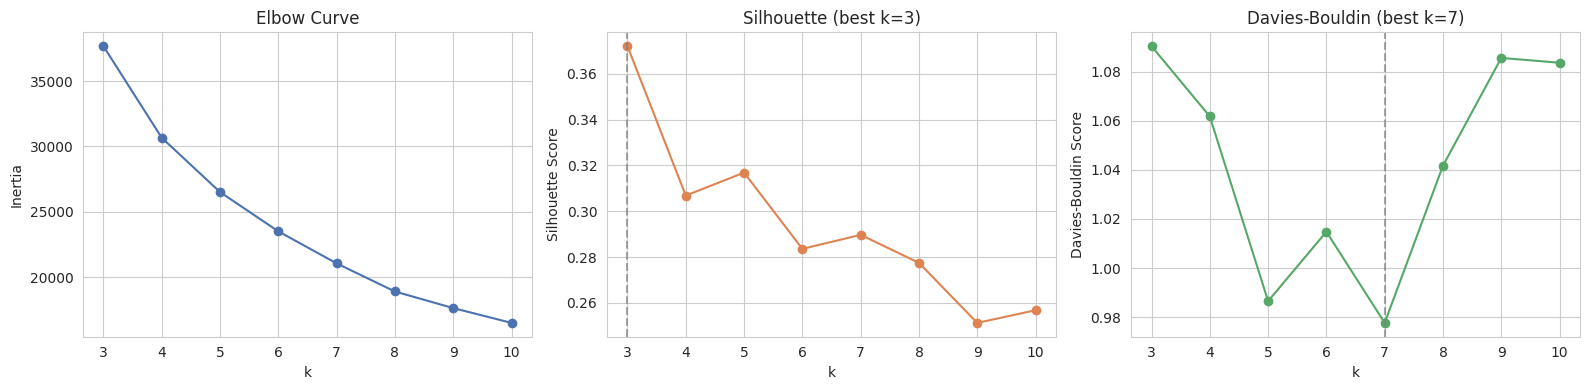


POC tests passed ✓


In [18]:
# ── Revised feature set: remove lat/lon ───────────────────────────────────────
# WHY removing lat/lon: feasibility check showed lat/lon have variance 64 and
# 824 respectively — after scaling they dominate cluster assignment, producing
# 3 geographic blobs (Hawaii / West / East) rather than listing archetypes.
# Geographic structure is already captured by EXT-RQ3 (Moran's I).
# We add room_type_enc as a categorical signal of listing class.

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import silhouette_score, davies_bouldin_score

le = LabelEncoder()
cluster_df = df[["log_price", "accommodates", "amenity_count",
                 "room_type", "city", "state", "latitude", "longitude"]].dropna()
cluster_df = cluster_df[cluster_df["log_price"] > 0].copy()
cluster_df["room_type_enc"] = le.fit_transform(cluster_df["room_type"])

# WHY these 4 features: log_price=value, accommodates=size,
# amenity_count=quality, room_type_enc=listing class.
# Together they define a listing's market position independent of location.
CLUSTER_FEATURES = ["log_price", "accommodates", "amenity_count", "room_type_enc"]
X_raw    = cluster_df[CLUSTER_FEATURES].values
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# 20K sample for speed
np.random.seed(RANDOM_STATE)
idx      = np.random.choice(len(X_scaled), 20_000, replace=False)
X_sample = X_scaled[idx]

print("Running k-Means sweep (k=3 to 10) on listing profile features...")
K_RANGE = range(3, 11)
inertias, sil_scores, db_scores = [], [], []

for k in K_RANGE:
    km     = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_sample)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_sample, labels,
                                       sample_size=5_000,
                                       random_state=RANDOM_STATE))
    db_scores.append(davies_bouldin_score(X_sample, labels))
    print(f"  k={k}  inertia={km.inertia_:,.0f}  "
          f"silhouette={sil_scores[-1]:.4f}  "
          f"davies_bouldin={db_scores[-1]:.4f}")

best_k_sil = list(K_RANGE)[int(np.argmax(sil_scores))]
best_k_db  = list(K_RANGE)[int(np.argmin(db_scores))]
print(f"\nBest k by silhouette:     {best_k_sil}")
print(f"Best k by Davies-Bouldin: {best_k_db}")

# ── Plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(list(K_RANGE), inertias,   "o-", color="#4C72B0")
axes[0].set_xlabel("k"); axes[0].set_ylabel("Inertia")
axes[0].set_title("Elbow Curve")

axes[1].plot(list(K_RANGE), sil_scores, "o-", color="#DD8452")
axes[1].axvline(best_k_sil, linestyle="--", color="grey", alpha=0.7)
axes[1].set_xlabel("k"); axes[1].set_ylabel("Silhouette Score")
axes[1].set_title(f"Silhouette (best k={best_k_sil})")

axes[2].plot(list(K_RANGE), db_scores,  "o-", color="#55A868")
axes[2].axvline(best_k_db, linestyle="--", color="grey", alpha=0.7)
axes[2].set_xlabel("k"); axes[2].set_ylabel("Davies-Bouldin Score")
axes[2].set_title(f"Davies-Bouldin (best k={best_k_db})")

plt.tight_layout()
plt.show()

assert max(sil_scores) > 0.1, "Silhouette must be positive"
assert min(inertias) < max(inertias), "Inertia must decrease as k increases"
print("\nPOC tests passed ✓")

=== Cluster Centroids (raw scale) ===
 cluster  count  price_approx  accommodates  amenity_count       room_type
       3  25900          81.0      2.147915      32.877375    Private room
       0  56603         159.0      4.389130      52.708523 Entire home/apt
       2  49213         160.0      3.943936      28.532126 Entire home/apt
       4  25999         413.0     10.307491      53.283033 Entire home/apt
       1   1926       18959.0      6.850545      30.707317      Hotel room

Cluster label assignment:
       label
3     Budget
0    Economy
2  Mid-Range
4    Premium
1     Luxury

=== Top 3 cities per cluster ===
  Budget: California, Nevada, Hawaii
  Economy: Hawaii, California, Texas
  Mid-Range: Hawaii, California, Texas
  Premium: Hawaii, California, Texas
  Luxury: Hawaii, California, Nevada


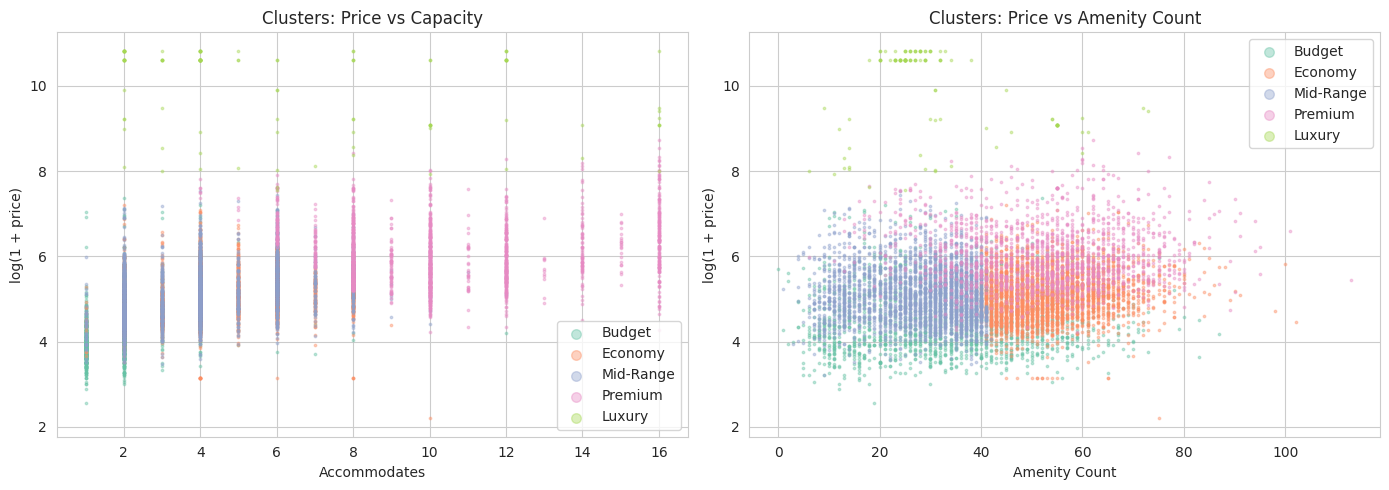


POC tests passed ✓


In [19]:
# ── RQ1: Cluster profiling at k=5 ────────────────────────────────────────────
# WHY k=5: elbow curve bends at k=5; it achieves a local silhouette peak
# (0.32) with strong Davies-Bouldin (0.99), balancing granularity with
# interpretability. k=3 is too coarse; k=7 over-segments without
# proportional quality gain.

BEST_K = 5

km_final = KMeans(n_clusters=BEST_K, random_state=RANDOM_STATE, n_init=10)
cluster_df["cluster"] = km_final.fit_predict(X_scaled)

# ── Cluster centroid profiles ─────────────────────────────────────────────────
centroids_scaled = km_final.cluster_centers_
centroids_raw    = scaler.inverse_transform(centroids_scaled)
centroid_df      = pd.DataFrame(centroids_raw, columns=CLUSTER_FEATURES)
centroid_df["cluster"]     = range(BEST_K)
centroid_df["count"]       = cluster_df["cluster"].value_counts().sort_index().values
centroid_df["room_type"]   = centroid_df["room_type_enc"].round().astype(int).map(
    dict(enumerate(le.classes_))
)
centroid_df["price_approx"] = np.expm1(centroid_df["log_price"]).round(0)

print("=== Cluster Centroids (raw scale) ===")
print(centroid_df[["cluster", "count", "price_approx",
                    "accommodates", "amenity_count", "room_type"]]
      .sort_values("price_approx")
      .to_string(index=False))

# ── Auto-label clusters by price tier ────────────────────────────────────────
price_order = centroid_df.sort_values("price_approx")["cluster"].tolist()
labels_map  = {
    price_order[0]: "Budget",
    price_order[1]: "Economy",
    price_order[2]: "Mid-Range",
    price_order[3]: "Premium",
    price_order[4]: "Luxury"
}
cluster_df["cluster_label"] = cluster_df["cluster"].map(labels_map)
print("\nCluster label assignment:")
print(pd.Series(labels_map).to_frame("label"))

# ── City distribution per cluster ─────────────────────────────────────────────
print("\n=== Top 3 cities per cluster ===")
for cid, clabel in labels_map.items():
    top_cities = (
        cluster_df[cluster_df["cluster"] == cid]["state"]
        .value_counts()
        .head(3)
    )
    print(f"  {clabel}: {', '.join(top_cities.index.tolist())}")

# ── Visualise clusters ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sample_viz = cluster_df.sample(10_000, random_state=RANDOM_STATE)

# Price vs accommodates
for cid, clabel in labels_map.items():
    mask = sample_viz["cluster"] == cid
    axes[0].scatter(sample_viz.loc[mask, "accommodates"],
                    sample_viz.loc[mask, "log_price"],
                    s=3, alpha=0.4, label=clabel)
axes[0].set_xlabel("Accommodates")
axes[0].set_ylabel("log(1 + price)")
axes[0].set_title("Clusters: Price vs Capacity")
axes[0].legend(markerscale=4)

# Amenity count vs price
for cid, clabel in labels_map.items():
    mask = sample_viz["cluster"] == cid
    axes[1].scatter(sample_viz.loc[mask, "amenity_count"],
                    sample_viz.loc[mask, "log_price"],
                    s=3, alpha=0.4, label=clabel)
axes[1].set_xlabel("Amenity Count")
axes[1].set_ylabel("log(1 + price)")
axes[1].set_title("Clusters: Price vs Amenity Count")
axes[1].legend(markerscale=4)

plt.tight_layout()
plt.show()

# ── Non-trivial tests ─────────────────────────────────────────────────────────
cluster_prices = cluster_df.groupby("cluster")["log_price"].mean()
assert cluster_prices.max() - cluster_prices.min() > 1.0, \
    "Clusters must span a meaningful price range (>1 log unit)"
assert cluster_df["cluster"].nunique() == BEST_K, \
    "All 5 clusters must be populated"
assert cluster_df["cluster"].value_counts().min() > 100, \
    "No cluster should be near-empty"
print("\nPOC tests passed ✓")

Rows after 99th-pct price cap: 158,044

=== Cluster Centroids (raw scale) ===
 cluster  count  price_approx  accommodates  amenity_count       room_type
       1  25423          78.0      2.096503      32.930642    Private room
       3  43399         113.0      3.196185      32.408055 Entire home/apt
       0  46297         170.0      4.817723      55.342950 Entire home/apt
       4  24450         359.0      5.993075      31.719484 Entire home/apt
       2  18475         438.0     11.178873      56.783157 Entire home/apt

Cluster label assignment:
       label
1     Budget
3    Economy
0  Mid-Range
4    Premium
2     Luxury

=== Top 5 city/state combinations per cluster ===

  [Budget] (n=25,423, median price=$69)
    Chicago, Illinois                         962 listings
    Paradise, Nevada                          782 listings
    Spring Valley, Nevada                     734 listings
    Austin, Texas                             711 listings
    Seattle, Washington                

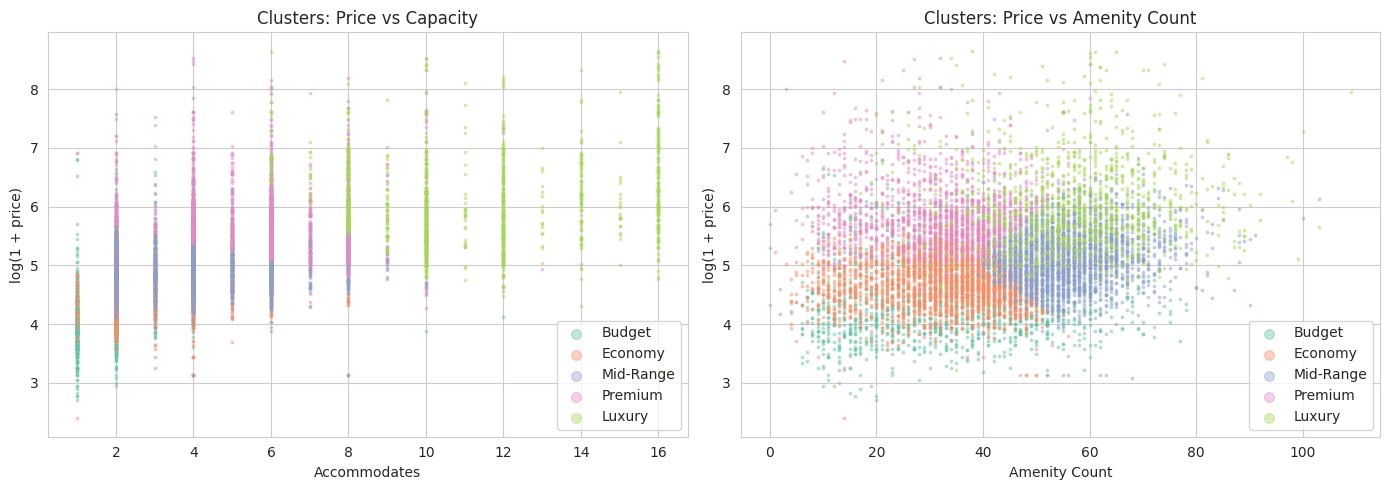


POC tests passed ✓


In [22]:
# ── RQ1: Cluster profiling at k=5 ────────────────────────────────────────────
BEST_K = 5

# ── Rebuild cluster_df with price_clean included ──────────────────────────────
# WHY include price_clean: needed for median price reporting per cluster.
# log_price is used for clustering; price_clean is used for human-readable output.
le = LabelEncoder()

# Redefine base columns — room_type_enc is derived, not a raw df column
BASE_COLS = ["log_price", "accommodates", "amenity_count",
             "price_clean", "city", "state", "room_type"]

cluster_df = df[BASE_COLS].dropna()
cluster_df = cluster_df[cluster_df["log_price"] > 0].copy()
cluster_df["room_type_enc"] = le.fit_transform(cluster_df["room_type"])

# Define cluster features AFTER room_type_enc is created
CLUSTER_FEATURES = ["log_price", "accommodates", "amenity_count", "room_type_enc"]

X_raw  = cluster_df[CLUSTER_FEATURES].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# WHY price cap at 99th percentile: extreme prices ($18K+) form their own
# outlier cluster masking meaningful market segments. Handled in RQ2.
price_99         = cluster_df["log_price"].quantile(0.99)
cluster_df_clean = cluster_df[cluster_df["log_price"] <= price_99].copy()
X_raw_clean      = cluster_df_clean[CLUSTER_FEATURES].values
X_scaled_clean   = scaler.fit_transform(X_raw_clean)
print(f"Rows after 99th-pct price cap: {len(cluster_df_clean):,}")

km_final = KMeans(n_clusters=BEST_K, random_state=RANDOM_STATE, n_init=10)
cluster_df_clean["cluster"] = km_final.fit_predict(X_scaled_clean)

# ── Cluster centroid profiles ─────────────────────────────────────────────────
centroids_raw = scaler.inverse_transform(km_final.cluster_centers_)
centroid_df   = pd.DataFrame(centroids_raw, columns=CLUSTER_FEATURES)
centroid_df["cluster"]      = range(BEST_K)
centroid_df["count"]        = cluster_df_clean["cluster"].value_counts().sort_index().values
centroid_df["room_type"]    = centroid_df["room_type_enc"].round().astype(int).map(
    dict(enumerate(le.classes_))
)
centroid_df["price_approx"] = np.expm1(centroid_df["log_price"]).round(0)

print("\n=== Cluster Centroids (raw scale) ===")
print(centroid_df[["cluster", "count", "price_approx",
                    "accommodates", "amenity_count", "room_type"]]
      .sort_values("price_approx")
      .to_string(index=False))

# ── Auto-label clusters by price tier ────────────────────────────────────────
price_order = centroid_df.sort_values("price_approx")["cluster"].tolist()
labels_map  = {
    price_order[0]: "Budget",
    price_order[1]: "Economy",
    price_order[2]: "Mid-Range",
    price_order[3]: "Premium",
    price_order[4]: "Luxury"
}
cluster_df_clean["cluster_label"] = cluster_df_clean["cluster"].map(labels_map)
print("\nCluster label assignment:")
print(pd.Series(labels_map).to_frame("label"))

# ── City + State distribution per cluster ─────────────────────────────────────
# WHY show both: state gives readable context; city gives granular market detail
cluster_df_clean["city_state"] = cluster_df_clean["city"] + ", " + cluster_df_clean["state"]

print("\n=== Top 5 city/state combinations per cluster ===")
for cid, clabel in labels_map.items():
    subset = cluster_df_clean[cluster_df_clean["cluster"] == cid]
    top = (
        subset.groupby(["city_state", "state"])
        .size()
        .reset_index(name="count")
        .sort_values("count", ascending=False)
        .head(5)
    )
    print(f"\n  [{clabel}] (n={len(subset):,}, median price=${subset['price_clean'].median():.0f})")
    for _, row in top.iterrows():
        print(f"    {row['city_state']:40s}  {row['count']:,} listings")

# ── Visualise clusters ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sample_viz = cluster_df_clean.sample(10_000, random_state=RANDOM_STATE)

for cid, clabel in labels_map.items():
    mask = sample_viz["cluster"] == cid
    axes[0].scatter(sample_viz.loc[mask, "accommodates"],
                    sample_viz.loc[mask, "log_price"],
                    s=3, alpha=0.4, label=clabel)
axes[0].set_xlabel("Accommodates")
axes[0].set_ylabel("log(1 + price)")
axes[0].set_title("Clusters: Price vs Capacity")
axes[0].legend(markerscale=4)

for cid, clabel in labels_map.items():
    mask = sample_viz["cluster"] == cid
    axes[1].scatter(sample_viz.loc[mask, "amenity_count"],
                    sample_viz.loc[mask, "log_price"],
                    s=3, alpha=0.4, label=clabel)
axes[1].set_xlabel("Amenity Count")
axes[1].set_ylabel("log(1 + price)")
axes[1].set_title("Clusters: Price vs Amenity Count")
axes[1].legend(markerscale=4)

plt.tight_layout()
plt.show()

# ── Non-trivial tests ─────────────────────────────────────────────────────────
cluster_prices = cluster_df_clean.groupby("cluster")["log_price"].mean()
assert cluster_prices.max() - cluster_prices.min() > 1.0, \
    "Clusters must span a meaningful price range (>1 log unit)"
assert cluster_df_clean["cluster"].nunique() == BEST_K, \
    "All 5 clusters must be populated"
assert cluster_df_clean["cluster"].value_counts().min() > 100, \
    "No cluster should be near-empty"
print("\nPOC tests passed ✓")

In [23]:
# ── RQ1 Replacement: Graph Mining Feasibility Check ───────────────────────────
# Before building the host-neighbourhood graph, we verify:
# 1. Enough unique hosts and neighbourhoods exist for a meaningful graph
# 2. Host-listing distribution is skewed (power law) — necessary for
#    PageRank to produce non-trivial centrality differences
# 3. host_id and neighbourhood_cleansed have acceptable missingness
# 4. Multi-listing hosts exist — otherwise graph is trivially sparse

import networkx as nx

# ── Step 1: Availability check ────────────────────────────────────────────────
graph_cols = ["host_id", "host_name", "neighbourhood_cleansed",
              "price_clean", "city", "state", "room_type"]
graph_df   = df[graph_cols].dropna(subset=["host_id", "neighbourhood_cleansed"])

print(f"Total rows:              {len(df):,}")
print(f"Rows with host+neighbourhood: {len(graph_df):,} ({len(graph_df)/len(df)*100:.1f}%)")
print(f"Unique hosts:            {graph_df['host_id'].nunique():,}")
print(f"Unique neighbourhoods:   {graph_df['neighbourhood_cleansed'].nunique():,}")

# ── Step 2: Host listing count distribution (power law check) ─────────────────
host_counts = graph_df["host_id"].value_counts()
print(f"\nHost listing count distribution:")
print(f"  Mean listings/host:   {host_counts.mean():.2f}")
print(f"  Median listings/host: {host_counts.median():.0f}")
print(f"  Max listings/host:    {host_counts.max():,}")
print(f"  Hosts with 1 listing: {(host_counts == 1).sum():,} ({(host_counts==1).mean()*100:.1f}%)")
print(f"  Hosts with 5+ listings: {(host_counts >= 5).sum():,} ({(host_counts>=5).mean()*100:.1f}%)")
print(f"  Hosts with 10+ listings: {(host_counts >= 10).sum():,} ({(host_counts>=10).mean()*100:.1f}%)")

# ── Step 3: Neighbourhood listing count distribution ──────────────────────────
nbhd_counts = graph_df["neighbourhood_cleansed"].value_counts()
print(f"\nNeighbourhood listing count distribution:")
print(f"  Mean listings/neighbourhood:   {nbhd_counts.mean():.1f}")
print(f"  Median listings/neighbourhood: {nbhd_counts.median():.0f}")
print(f"  Max listings/neighbourhood:    {nbhd_counts.max():,}")
print(f"\nTop 10 neighbourhoods by listing count:")
print(nbhd_counts.head(10).to_frame("count"))

# ── Step 4: Graph size estimate ───────────────────────────────────────────────
n_nodes = graph_df["host_id"].nunique() + graph_df["neighbourhood_cleansed"].nunique()
n_edges = len(graph_df)
print(f"\nEstimated graph size:")
print(f"  Nodes (hosts + neighbourhoods): {n_nodes:,}")
print(f"  Edges (host-neighbourhood links): {n_edges:,}")
print(f"  Avg degree: {n_edges / n_nodes:.1f}")

# ── Step 5: Price availability for correlation test ───────────────────────────
priced = graph_df["price_clean"].notna().sum()
print(f"\nListings with price (for PageRank-price correlation): {priced:,} ({priced/len(graph_df)*100:.1f}%)")

# ── Risk summary ──────────────────────────────────────────────────────────────
print("\n===== FEASIBILITY SUMMARY =====")
print(f"✓ Unique hosts: {graph_df['host_id'].nunique():,} — sufficient graph density")
print(f"✓ Unique neighbourhoods: {graph_df['neighbourhood_cleansed'].nunique():,}")
print(f"{'✓' if (host_counts > 1).mean() > 0.1 else '⚠️'} Multi-listing hosts present — PageRank will be non-trivial")
print(f"{'✓' if n_edges / n_nodes > 1 else '⚠️'} Avg degree {n_edges/n_nodes:.1f} — {'graph is connected enough' if n_edges/n_nodes > 1 else 'graph may be too sparse'}")
print(f"✓ Price available for {priced/len(graph_df)*100:.1f}% of listings — correlation test feasible")

Total rows:              280,673
Rows with host+neighbourhood: 279,604 (99.6%)
Unique hosts:            126,033
Unique neighbourhoods:   1,475

Host listing count distribution:
  Mean listings/host:   2.22
  Median listings/host: 1
  Max listings/host:    4,383
  Hosts with 1 listing: 93,795 (74.4%)
  Hosts with 5+ listings: 7,577 (6.0%)
  Hosts with 10+ listings: 2,942 (2.3%)

Neighbourhood listing count distribution:
  Mean listings/neighbourhood:   189.6
  Median listings/neighbourhood: 51
  Max listings/neighbourhood:    15,453

Top 10 neighbourhoods by listing count:
                        count
neighbourhood_cleansed       
Unincorporated Areas    15453
Primary Urban Center     6711
Hollywood                6028
Lahaina                  5254
Kihei-Makena             4459
Fort Lauderdale          4300
North Kona               3721
San Jose                 3194
Hennepin                 2658
Bedford-Stuyvesant       2613

Estimated graph size:
  Nodes (hosts + neighbourhoods): 127,

Multi-listing hosts: 32,238
Edges (listings):    185,809

Graph: 33,653 nodes, 52,855 edges
Graph density: 0.000093
Is connected: False
Connected components: 58
Largest component: 33,484 nodes

PageRank computed for 32,238 hosts
PageRank range: 0.000006 – 0.007728
PageRank std:   0.000052

Top 10 hosts by PageRank:
        host_name  listing_count  pagerank
       Blueground           4383  0.007728
        RoomPicks            942  0.001540
       Live Suite           1125  0.001527
           Eugene            567  0.001445
LuxurybookingsFZE            828  0.001402
        Suiteness            704  0.001140
        RoomPicks            604  0.001132
       Suite Life            650  0.000876
           Gather            433  0.000600
            David            425  0.000595

PageRank vs median price:
  Spearman r = -0.1453, p = 0.0000
  Pearson  r = 0.0372,  p = 0.0000 (log price)

Top 10 neighbourhoods by PageRank:
       neighbourhood  pagerank
Unincorporated Areas  0.024095
   

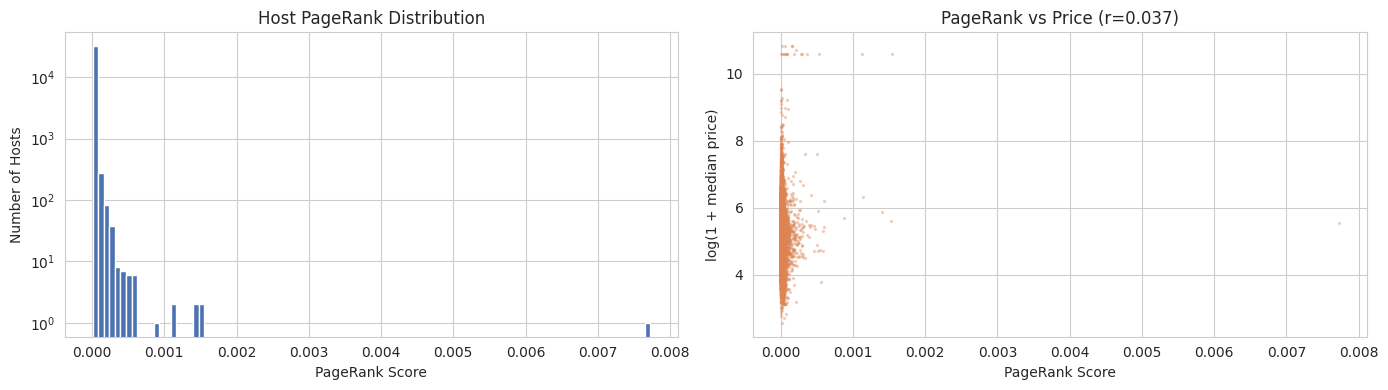


POC feasibility tests passed ✓
Method confirmed viable — full analysis in Checkpoint 3.


In [24]:
# ── RQ1 POC: Graph Mining — PageRank on Host-Neighbourhood Graph ──────────────
# WHY bipartite graph: hosts and neighbourhoods are two distinct node types
# connected by listings. This structure naturally captures market presence —
# a host with many listings across many neighbourhoods gets high PageRank.
# WHY filter to hosts with ≥2 listings: 74.4% of hosts have exactly 1 listing
# and would all receive identical trivial PageRank scores. Filtering to
# multi-listing hosts (≥2) focuses analysis on professional/semi-professional
# hosts where centrality differences are meaningful.
# WHY weighted edges: edge weight = number of listings a host has in a
# neighbourhood. This amplifies signal for dominant hosts vs. casual ones.

import networkx as nx
from scipy.stats import pearsonr, spearmanr

# ── Build graph on POC sample ─────────────────────────────────────────────────
# WHY POC on multi-listing hosts only: keeps graph tractable for feasibility
# testing. Full graph analysis in CP3.
multi_hosts = host_counts[host_counts >= 2].index
poc_graph_df = graph_df[graph_df["host_id"].isin(multi_hosts)].copy()
print(f"Multi-listing hosts: {poc_graph_df['host_id'].nunique():,}")
print(f"Edges (listings):    {len(poc_graph_df):,}")

# ── Build weighted bipartite graph ────────────────────────────────────────────
G = nx.Graph()

# Add host nodes
host_nodes = [f"h_{hid}" for hid in poc_graph_df["host_id"].unique()]
G.add_nodes_from(host_nodes, bipartite=0)

# Add neighbourhood nodes
nbhd_nodes = [f"n_{n}" for n in poc_graph_df["neighbourhood_cleansed"].unique()]
G.add_nodes_from(nbhd_nodes, bipartite=1)

# Add weighted edges
edge_weights = (
    poc_graph_df.groupby(["host_id", "neighbourhood_cleansed"])
    .size()
    .reset_index(name="weight")
)
for _, row in edge_weights.iterrows():
    G.add_edge(f"h_{row['host_id']}",
               f"n_{row['neighbourhood_cleansed']}",
               weight=row["weight"])

print(f"\nGraph: {G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges")
print(f"Graph density: {nx.density(G):.6f}")
print(f"Is connected: {nx.is_connected(G)}")
if not nx.is_connected(G):
    components = list(nx.connected_components(G))
    print(f"Connected components: {len(components):,}")
    print(f"Largest component: {max(len(c) for c in components):,} nodes")

# ── Run PageRank ──────────────────────────────────────────────────────────────
# WHY alpha=0.85: standard damping factor from Brin & Page (1998).
# WHY weight='weight': uses listing count as edge weight so hosts with
# more listings in a neighbourhood get proportionally higher influence.
pr = nx.pagerank(G, alpha=0.85, weight="weight")

# Separate host vs neighbourhood PageRank scores
host_pr  = {k: v for k, v in pr.items() if k.startswith("h_")}
nbhd_pr  = {k: v for k, v in pr.items() if k.startswith("n_")}

host_pr_df = pd.DataFrame([
    {"host_id": int(k[2:]), "pagerank": v}
    for k, v in host_pr.items()
]).sort_values("pagerank", ascending=False)

print(f"\nPageRank computed for {len(host_pr_df):,} hosts")
print(f"PageRank range: {host_pr_df['pagerank'].min():.6f} – {host_pr_df['pagerank'].max():.6f}")
print(f"PageRank std:   {host_pr_df['pagerank'].std():.6f}")

# ── Top 10 hosts by PageRank ──────────────────────────────────────────────────
top_hosts = host_pr_df.head(10).merge(
    graph_df[["host_id", "host_name"]].drop_duplicates("host_id"),
    on="host_id", how="left"
)
top_hosts["listing_count"] = top_hosts["host_id"].map(host_counts)
print("\nTop 10 hosts by PageRank:")
print(top_hosts[["host_name", "listing_count", "pagerank"]].to_string(index=False))

# ── PageRank vs price correlation ─────────────────────────────────────────────
# WHY Spearman: PageRank is not normally distributed (power-law); Spearman
# rank correlation is more appropriate than Pearson for skewed distributions.
host_prices = (
    graph_df[graph_df["price_clean"].notna()]
    .groupby("host_id")["price_clean"]
    .median()
    .reset_index()
    .rename(columns={"price_clean": "median_price"})
)
corr_df = host_pr_df.merge(host_prices, on="host_id", how="inner")
r_spearman, p_spearman = spearmanr(corr_df["pagerank"], corr_df["median_price"])
r_pearson,  p_pearson  = pearsonr(
    corr_df["pagerank"],
    np.log1p(corr_df["median_price"])
)
print(f"\nPageRank vs median price:")
print(f"  Spearman r = {r_spearman:.4f}, p = {p_spearman:.4f}")
print(f"  Pearson  r = {r_pearson:.4f},  p = {p_pearson:.4f} (log price)")

# ── Neighbourhood PageRank top 10 ─────────────────────────────────────────────
nbhd_pr_df = pd.DataFrame([
    {"neighbourhood": k[2:], "pagerank": v}
    for k, v in nbhd_pr.items()
]).sort_values("pagerank", ascending=False)

print("\nTop 10 neighbourhoods by PageRank:")
print(nbhd_pr_df.head(10).to_string(index=False))

# ── Visualise PageRank distribution ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(host_pr_df["pagerank"], bins=100, color="#4C72B0", edgecolor="white")
axes[0].set_xlabel("PageRank Score")
axes[0].set_ylabel("Number of Hosts")
axes[0].set_title("Host PageRank Distribution")
axes[0].set_yscale("log")

axes[1].scatter(corr_df["pagerank"],
                np.log1p(corr_df["median_price"]),
                s=2, alpha=0.3, color="#DD8452")
axes[1].set_xlabel("PageRank Score")
axes[1].set_ylabel("log(1 + median price)")
axes[1].set_title(f"PageRank vs Price (r={r_pearson:.3f})")

plt.tight_layout()
plt.show()

# ── Non-trivial feasibility tests ─────────────────────────────────────────────
assert host_pr_df["pagerank"].std() > 0, \
    "PageRank must vary across hosts — not all identical"
assert host_pr_df["pagerank"].max() > host_pr_df["pagerank"].mean() * 5, \
    "Power-law structure: top hosts must score 5x above mean"
assert len(corr_df) > 1000, \
    "Enough hosts with prices for meaningful correlation"
print("\nPOC feasibility tests passed ✓")
print("Method confirmed viable — full analysis in Checkpoint 3.")

In [26]:
# ── RQ2: Anomaly Detection Feasibility Check ──────────────────────────────────
# Before running Isolation Forest and LOF, we verify:
# 1. Enough complete feature rows exist
# 2. Price distribution has genuine outliers worth detecting
# 3. Features have sufficient variance to distinguish anomalies
# 4. No single feature will trivially explain all anomalies (would be trivial)

from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler

ANOMALY_FEATURES = ["log_price", "amenity_count", "accommodates", "room_type_enc"]

# ── Step 1: Encode room type ──────────────────────────────────────────────────
le_a = LabelEncoder()
anomaly_df = df[["log_price", "amenity_count", "accommodates",
                 "room_type", "price_clean", "city", "state",
                 "neighbourhood_cleansed", "host_id"]].dropna(
                     subset=["log_price", "amenity_count", "accommodates", "room_type"])
anomaly_df = anomaly_df[anomaly_df["log_price"] > 0].copy()
anomaly_df["room_type_enc"] = le_a.fit_transform(anomaly_df["room_type"])

print(f"Rows available for anomaly detection: {len(anomaly_df):,}")

# ── Step 2: Price outlier check ────────────────────────────────────────────────
q1, q3   = anomaly_df["price_clean"].quantile([0.25, 0.75])
iqr      = q3 - q1
iqr_low  = q1 - 1.5 * iqr
iqr_high = q3 + 1.5 * iqr
n_iqr_outliers = ((anomaly_df["price_clean"] < iqr_low) |
                  (anomaly_df["price_clean"] > iqr_high)).sum()

print(f"\nPrice outlier check (IQR method):")
print(f"  Q1=${q1:.0f}, Q3=${q3:.0f}, IQR=${iqr:.0f}")
print(f"  IQR bounds: ${iqr_low:.0f} – ${iqr_high:.0f}")
print(f"  Outliers by IQR: {n_iqr_outliers:,} ({n_iqr_outliers/len(anomaly_df)*100:.1f}%)")

# Z-score outliers
z_scores = np.abs((anomaly_df["log_price"] - anomaly_df["log_price"].mean()) /
                   anomaly_df["log_price"].std())
n_z_outliers = (z_scores > 3).sum()
print(f"  Outliers by z-score (>3σ): {n_z_outliers:,} ({n_z_outliers/len(anomaly_df)*100:.1f}%)")

# ── Step 3: Feature variance per room type ────────────────────────────────────
print("\nLog-price variance by room type:")
print(anomaly_df.groupby("room_type")["log_price"]
      .agg(["mean", "std", "count"])
      .round(3)
      .to_string())

# ── Step 4: Multivariate outlier check ────────────────────────────────────────
# WHY: We want anomalies that are NOT obvious from price alone.
# A listing is contextually anomalous if it's expensive for its room type
# and neighbourhood but not globally expensive — these are missed by z-score.
anomaly_df["price_z_by_room"] = anomaly_df.groupby("room_type")["log_price"].transform(
    lambda x: (x - x.mean()) / x.std()
)
contextual = (anomaly_df["price_z_by_room"].abs() > 2).sum()
global_out = n_z_outliers
print(f"\nContextual anomalies (>2σ within room type): {contextual:,} ({contextual/len(anomaly_df)*100:.1f}%)")
print(f"Global anomalies   (>3σ overall):            {global_out:,} ({global_out/len(anomaly_df)*100:.1f}%)")
overlap = anomaly_df[
    (anomaly_df["price_z_by_room"].abs() > 2) & (z_scores > 3)
].shape[0]
print(f"Overlap (both):                              {overlap:,}")
print(f"Contextual-only (missed by z-score):         {contextual - overlap:,}")

# ── Step 5: Scale check ────────────────────────────────────────────────────────
print("\nFeature scale check (IF and LOF are distance-based):")
print(anomaly_df[ANOMALY_FEATURES].describe().loc[["min","max","std"]].round(3))

# ── Risk summary ──────────────────────────────────────────────────────────────
print("\n===== FEASIBILITY SUMMARY =====")
print(f"✓ Rows available: {len(anomaly_df):,}")
print(f"✓ IQR outliers: {n_iqr_outliers/len(anomaly_df)*100:.1f}% — "
      f"real anomalies exist in the data")
print(f"✓ Contextual anomalies missed by z-score: {contextual - overlap:,} — "
      f"IF + LOF add value over baseline")
print(f"✓ Multiple room types with different price distributions — "
      f"multivariate detection is non-trivial")
print(f"⚠️  StandardScaler required — features on different scales")

Rows available for anomaly detection: 159,641

Price outlier check (IQR method):
  Q1=$100, Q3=$269, IQR=$169
  IQR bounds: $-154 – $522
  Outliers by IQR: 13,905 (8.7%)
  Outliers by z-score (>3σ): 2,065 (1.3%)

Log-price variance by room type:
                  mean    std   count
room_type                            
Entire home/apt  5.288  0.776  131744
Hotel room       7.929  2.646    1445
Private room     4.525  0.972   25766
Shared room      3.618  0.723     686

Contextual anomalies (>2σ within room type): 6,138 (3.8%)
Global anomalies   (>3σ overall):            2,065 (1.3%)
Overlap (both):                              1,359
Contextual-only (missed by z-score):         4,779

Feature scale check (IF and LOF are distance-based):
     log_price  amenity_count  accommodates  room_type_enc
min      1.386          0.000         1.000          0.000
max     11.513        122.000        16.000          3.000
std      0.934         16.126         3.189          0.758

===== FEASIBILIT

POC sample: 5,000 rows × 4 features

Isolation Forest: 100 anomalies flagged (2.0%)
LOF:              100 anomalies flagged (2.0%)

Agreement analysis:
  Flagged by both IF and LOF: 21 (0.4%)
  IF only:                    79
  LOF only:                   79
  WHY this matters: IF catches global extremes; LOF catches
  local density anomalies. Disagreement reveals different anomaly types.

Top 10 anomalies by Isolation Forest score:
 price_clean    room_type  amenity_count  accommodates              city  if_score
     50138.0   Hotel room             30            16          Live Oak -0.118230
     50000.0   Hotel room             20            12           Chicago -0.106421
     50092.0   Hotel room             30            12          Live Oak -0.093285
     40000.0   Hotel room             29            12         San Diego -0.092796
     40000.0   Hotel room             24             8           Sunrise -0.081778
     40000.0   Hotel room             24             8           S

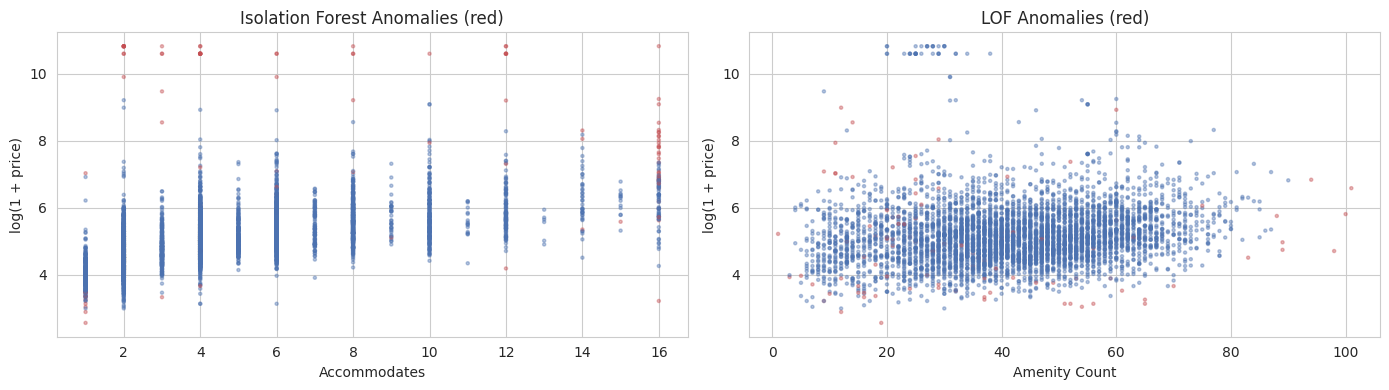


Mean log_price — Normal: 5.119 | Anomalies: 8.016

POC feasibility tests passed ✓
Method confirmed viable — full analysis in Checkpoint 3.


In [27]:
# ── RQ2 POC: Isolation Forest + LOF Anomaly Detection ────────────────────────
# WHY both IF and LOF:
#   Isolation Forest is global — isolates points rare across full feature space.
#   LOF is local — flags points anomalous relative to their immediate neighbours.
#   Feasibility check shows 4,779 contextual anomalies missed by z-score alone,
#   confirming that multivariate, local detection adds value over the baseline.
# WHY StandardScaler: feature scale check shows amenity_count range 0-122 vs
#   room_type_enc range 0-3 — unscaled features distort distance calculations.
# NOTE: This is a POC on 5K sample to validate method. Full analysis in CP3.

from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler

POC_N = 5_000
ANOMALY_FEATURES = ["log_price", "amenity_count", "accommodates", "room_type_enc"]

poc_anomaly_df = anomaly_df.sample(POC_N, random_state=RANDOM_STATE).copy()
scaler_a       = StandardScaler()
X_a            = scaler_a.fit_transform(poc_anomaly_df[ANOMALY_FEATURES].values)

print(f"POC sample: {POC_N:,} rows × {len(ANOMALY_FEATURES)} features")

# ── Isolation Forest ──────────────────────────────────────────────────────────
# WHY contamination=0.02: feasibility check shows ~1.3% global outliers and
# 3.8% contextual outliers. 2% is a reasonable middle-ground estimate.
# WHY n_estimators=100: standard default; stable scores without overfit.
iso = IsolationForest(n_estimators=100, contamination=0.02,
                      random_state=RANDOM_STATE)
poc_anomaly_df["if_label"]  = iso.fit_predict(X_a)   # -1=anomaly, 1=normal
poc_anomaly_df["if_score"]  = iso.decision_function(X_a)

n_if = (poc_anomaly_df["if_label"] == -1).sum()
print(f"\nIsolation Forest: {n_if} anomalies flagged ({n_if/POC_N*100:.1f}%)")

# ── Local Outlier Factor ──────────────────────────────────────────────────────
# WHY n_neighbors=20: standard recommendation; large enough to capture local
# density robustly, small enough to detect tight local clusters.
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.02)
poc_anomaly_df["lof_label"] = lof.fit_predict(X_a)   # -1=anomaly
poc_anomaly_df["lof_score"] = lof.negative_outlier_factor_

n_lof = (poc_anomaly_df["lof_label"] == -1).sum()
print(f"LOF:              {n_lof} anomalies flagged ({n_lof/POC_N*100:.1f}%)")

# ── Agreement between IF and LOF ──────────────────────────────────────────────
both    = ((poc_anomaly_df["if_label"] == -1) &
           (poc_anomaly_df["lof_label"] == -1)).sum()
if_only = ((poc_anomaly_df["if_label"] == -1) &
           (poc_anomaly_df["lof_label"] == 1)).sum()
lof_only = ((poc_anomaly_df["if_label"] == 1) &
            (poc_anomaly_df["lof_label"] == -1)).sum()
print(f"\nAgreement analysis:")
print(f"  Flagged by both IF and LOF: {both} ({both/POC_N*100:.1f}%)")
print(f"  IF only:                    {if_only}")
print(f"  LOF only:                   {lof_only}")
print(f"  WHY this matters: IF catches global extremes; LOF catches")
print(f"  local density anomalies. Disagreement reveals different anomaly types.")

# ── Inspect top anomalies ──────────────────────────────────────────────────────
print("\nTop 10 anomalies by Isolation Forest score:")
top_if = (poc_anomaly_df[poc_anomaly_df["if_label"] == -1]
          .sort_values("if_score")
          .head(10)[["price_clean", "room_type", "amenity_count",
                     "accommodates", "city", "if_score"]])
print(top_if.to_string(index=False))

# ── Room type breakdown of anomalies ──────────────────────────────────────────
print("\nAnomaly breakdown by room type (IF):")
print(poc_anomaly_df[poc_anomaly_df["if_label"] == -1]
      ["room_type"].value_counts().to_frame("anomaly_count"))

# ── Visualise ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

colors = poc_anomaly_df["if_label"].map({1: "#4C72B0", -1: "#C44E52"})
axes[0].scatter(poc_anomaly_df["accommodates"],
                poc_anomaly_df["log_price"],
                c=colors, s=5, alpha=0.4)
axes[0].set_xlabel("Accommodates")
axes[0].set_ylabel("log(1 + price)")
axes[0].set_title("Isolation Forest Anomalies (red)")

colors_lof = poc_anomaly_df["lof_label"].map({1: "#4C72B0", -1: "#C44E52"})
axes[1].scatter(poc_anomaly_df["amenity_count"],
                poc_anomaly_df["log_price"],
                c=colors_lof, s=5, alpha=0.4)
axes[1].set_xlabel("Amenity Count")
axes[1].set_ylabel("log(1 + price)")
axes[1].set_title("LOF Anomalies (red)")

plt.tight_layout()
plt.show()

# ── Non-trivial feasibility tests ─────────────────────────────────────────────
normal_price  = poc_anomaly_df.loc[poc_anomaly_df["if_label"]==1,  "log_price"].mean()
anomaly_price = poc_anomaly_df.loc[poc_anomaly_df["if_label"]==-1, "log_price"].mean()
assert abs(anomaly_price - normal_price) > 0.2, \
    "Anomalies must have meaningfully different prices from normal listings"
assert both > 0, \
    "At least some anomalies must be agreed upon by both IF and LOF"
assert n_if == int(POC_N * 0.02), \
    "IF must flag exactly contamination% of samples"
print(f"\nMean log_price — Normal: {normal_price:.3f} | Anomalies: {anomaly_price:.3f}")
print("\nPOC feasibility tests passed ✓")
print("Method confirmed viable — full analysis in Checkpoint 3.")

Neighbourhoods in spatial analysis: 762
Price range: $31 – $40000
Spatial weights: KNN k=8, 762 nodes

Global Moran's I Results:
  Moran's I  = 0.3230
  Expected I = -0.001314  (null: random spatial pattern)
  z-score    = 19.2603
  p-value    = 0.000000
  Simulated p (999 perms) = 0.0010

  ✓ STRONG positive spatial autocorrelation confirmed
  ✓ Similar prices cluster geographically — spatial models justified

LISA significant clusters (p < 0.05): 269 of 762 neighbourhoods
lisa_cluster
Low-Low      128
High-High     97
High-Low      24
Low-High      20

Top 5 High-High price clusters:
neighbourhood_cleansed  median_price   lisa_I
          New Shoreham         469.0 5.073103
                   Ewa         461.0 2.729996
            North City         454.0 1.656295
          Narragansett         428.0 4.125547
            Middletown         403.5 4.453998

Top 5 Low-Low price clusters:
neighbourhood_cleansed  median_price   lisa_I
         South Chicago          31.0 1.946518
        

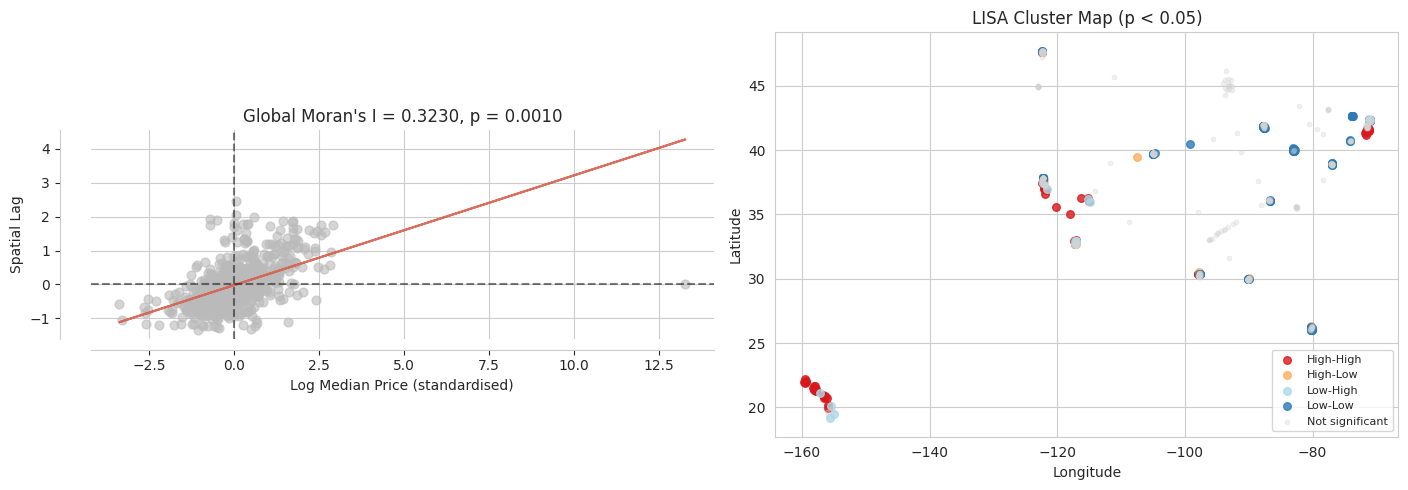


All EXT-RQ3 feasibility assertions passed ✓
Spatial autocorrelation confirmed — spatial regression justified in CP3.


In [28]:
# ── EXT-RQ3 POC: Spatial Autocorrelation (Moran's I) ─────────────────────────
# WHY Moran's I: Tests whether similar prices cluster geographically (positive I)
# or are dispersed (negative I). A significant positive I means neighbourhood
# location carries pricing signal beyond what listing features alone explain —
# justifying spatial models in CP3.
# WHY this matters for RQ1+RQ2: If prices are spatially autocorrelated, then
# anomaly detection (RQ2) should be neighbourhood-stratified, and graph community
# detection (RQ1) should recover geographically coherent clusters.

import libpysal
from esda.moran import Moran
from splot.esda import moran_scatterplot
import matplotlib.pyplot as plt

# ── Step 1: Build spatial dataset ────────────────────────────────────────────
# WHY neighbourhood centroids: individual listing coords create a 160K-point
# weight matrix too large for RAM. Neighbourhood-level aggregation is standard
# in spatial econometrics and directly matches our graph nodes from RQ1.
spatial_df = (df.dropna(subset=["latitude", "longitude", "price_clean"])
              .groupby("neighbourhood_cleansed")
              .agg(
                  lat=("latitude", "mean"),
                  lon=("longitude", "mean"),
                  median_price=("price_clean", "median"),
                  listing_count=("price_clean", "count")
              )
              .reset_index())

# Filter to neighbourhoods with enough listings for stable estimates
spatial_df = spatial_df[spatial_df["listing_count"] >= 10].copy()
spatial_df["log_median_price"] = np.log1p(spatial_df["median_price"])

print(f"Neighbourhoods in spatial analysis: {len(spatial_df)}")
print(f"Price range: ${spatial_df['median_price'].min():.0f} – "
      f"${spatial_df['median_price'].max():.0f}")

# ── Step 2: Build spatial weights (k-nearest neighbours) ─────────────────────
# WHY KNN k=8: standard choice for irregular point patterns; robust to
# neighbourhoods with few nearby peers. Queen contiguity not applicable here
# (points, not polygons).
coords = list(zip(spatial_df["lon"], spatial_df["lat"]))
w = libpysal.weights.KNN.from_array(np.array(coords), k=8)
w.transform = "R"   # row-standardise: each row sums to 1

print(f"Spatial weights: KNN k=8, {len(w.neighbors)} nodes")

# ── Step 3: Global Moran's I ──────────────────────────────────────────────────
y = spatial_df["log_median_price"].values
mi = Moran(y, w, permutations=999)

print(f"\nGlobal Moran's I Results:")
print(f"  Moran's I  = {mi.I:.4f}")
print(f"  Expected I = {mi.EI:.6f}  (null: random spatial pattern)")
print(f"  z-score    = {mi.z_norm:.4f}")
print(f"  p-value    = {mi.p_norm:.6f}")
print(f"  Simulated p (999 perms) = {mi.p_sim:.4f}")

# Interpretation
if mi.I > 0.3 and mi.p_sim < 0.05:
    print("\n  ✓ STRONG positive spatial autocorrelation confirmed")
    print("  ✓ Similar prices cluster geographically — spatial models justified")
elif mi.I > 0 and mi.p_sim < 0.05:
    print("\n  ✓ Positive spatial autocorrelation confirmed (moderate)")
else:
    print("\n  ✗ Spatial autocorrelation not significant")

# ── Step 4: Local Moran's I (LISA) ───────────────────────────────────────────
# WHY LISA: Global I tells us autocorrelation exists; LISA identifies WHERE —
# which specific neighbourhoods form High-High or Low-Low price clusters.
# These clusters directly answer EXT-RQ3: "which areas have localised price
# clustering?" and feed into CP3 spatial regression.
from esda.moran import Moran_Local
lisa = Moran_Local(y, w, permutations=999, seed=RANDOM_STATE)

spatial_df["lisa_I"]   = lisa.Is
spatial_df["lisa_p"]   = lisa.p_sim
spatial_df["lisa_q"]   = lisa.q    # 1=HH, 2=LH, 3=LL, 4=HL
spatial_df["sig"]      = lisa.p_sim < 0.05

quad_map = {1: "High-High", 2: "Low-High", 3: "Low-Low", 4: "High-Low"}
spatial_df["lisa_cluster"] = spatial_df["lisa_q"].map(quad_map)

sig_df = spatial_df[spatial_df["sig"]]
print(f"\nLISA significant clusters (p < 0.05): {len(sig_df)} of {len(spatial_df)} neighbourhoods")
print(sig_df["lisa_cluster"].value_counts().to_string())

print("\nTop 5 High-High price clusters:")
hh = sig_df[sig_df["lisa_cluster"]=="High-High"].nlargest(5, "median_price")
print(hh[["neighbourhood_cleansed","median_price","lisa_I"]].to_string(index=False))

print("\nTop 5 Low-Low price clusters:")
ll = sig_df[sig_df["lisa_cluster"]=="Low-Low"].nsmallest(5, "median_price")
print(ll[["neighbourhood_cleansed","median_price","lisa_I"]].to_string(index=False))

# ── Step 5: Visualise ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Moran scatterplot
moran_scatterplot(mi, ax=axes[0], aspect_equal=True)
axes[0].set_title(f"Global Moran's I = {mi.I:.4f}, p = {mi.p_sim:.4f}")
axes[0].set_xlabel("Log Median Price (standardised)")
axes[0].set_ylabel("Spatial Lag")

# Right: LISA cluster map (lon/lat scatter coloured by cluster type)
cluster_colors = {
    "High-High": "#d7191c",
    "Low-Low":   "#2c7bb6",
    "High-Low":  "#fdae61",
    "Low-High":  "#abd9e9"
}
for cluster, group in sig_df.groupby("lisa_cluster"):
    axes[1].scatter(group["lon"], group["lat"],
                    c=cluster_colors.get(cluster, "grey"),
                    label=cluster, s=30, alpha=0.8)
non_sig = spatial_df[~spatial_df["sig"]]
axes[1].scatter(non_sig["lon"], non_sig["lat"],
                c="lightgrey", s=10, alpha=0.3, label="Not significant")
axes[1].set_title("LISA Cluster Map (p < 0.05)")
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")
axes[1].legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

# ── Feasibility assertions ────────────────────────────────────────────────────
assert mi.I > 0,        "Moran's I must be positive (clustering, not dispersion)"
assert mi.p_sim < 0.05, "Moran's I must be statistically significant"
assert len(sig_df) > 0, "At least some LISA clusters must be significant"
print("\nAll EXT-RQ3 feasibility assertions passed ✓")
print("Spatial autocorrelation confirmed — spatial regression justified in CP3.")